PHASE ONE

1. Importing the necessary libraries

In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import os

print('All libraries loaded successfully!')

All libraries loaded successfully!


2. Loading the datasets

In [87]:
df = pd.read_csv(r"C:\Users\DELL\Downloads\Nairobi propertyprices - Sheet1.csv")
print('Dataset shape:', df.shape)
df.head()

Dataset shape: (204, 7)


,Price,propertyType,Location,Bedroom,bathroom,House size,Land size
0,KSh 350 000 000,Townhouse,Runda,4.0,4.0,NaN,0.5 acres
1,KSh 30 000 000,Vacant Land,Karen,NaN,NaN,NaN,0.5 acres
2,KSh 325 000 000,Vacant Land,Westlands,NaN,NaN,NaN,0.5 acres
3,KSh 80 000 000,Townhouse,Kitisuru,5.0,5.0,NaN,0.5 acres
4,KSh 25 500 000,Apartment,Kileleshwa,4.0,4.0,230 m²,NaN


In [88]:
df

,Price,propertyType,Location,Bedroom,bathroom,House size,Land size
0,KSh 350 000 000,Townhouse,Runda,4.0,4.0,NaN,0.5 acres
1,KSh 30 000 000,Vacant Land,Karen,NaN,NaN,NaN,0.5 acres
2,KSh 325 000 000,Vacant Land,Westlands,NaN,NaN,NaN,0.5 acres
3,KSh 80 000 000,Townhouse,Kitisuru,5.0,5.0,NaN,0.5 acres
4,KSh 25 500 000,Apartment,Kileleshwa,4.0,4.0,230 m²,NaN
...,...,...,...,...,...,...,...
199,KSh 6 000 000,Apartment,Westlands,1.0,1.0,60 m²,NaN
200,Ksh 200 000 000,Townhouse,Runda,8.0,7.0,NaN,0.5 acres
201,Ksh 9 500 000,Apartment,Nairobi West,2.0,2.0,NaN,NaN
202,KSh 12 500 000,Apartment,Kilimani,2.0,1.0,96 m²,NaN


3. Inspection

In [89]:
print('Column names:', df.columns.tolist())

Column names: ['Price', 'propertyType', 'Location', 'Bedroom', 'bathroom', 'House size', 'Land size']


In [90]:
print('\nData types:')
print(df.dtypes)


Data types:
Price            object
propertyType     object
Location         object
Bedroom         float64
bathroom        float64
House size       object
Land size        object
dtype: object


In [91]:
print('\nMissing values:')
print(df.isnull().sum())


Missing values:
Price             0
propertyType      0
Location          0
Bedroom          21
bathroom         23
House size      105
Land size       140
dtype: int64


In [92]:
print('\nBasic statistics:')
df.describe()


Basic statistics:


,Bedroom,bathroom
count,183.000000,181.000000
mean,3.513661,2.906077
std,1.585851,1.628570
min,1.000000,1.000000
25%,2.000000,2.000000
50%,4.000000,2.000000
75%,5.000000,4.000000
max,8.000000,8.000000


4. Data cleaning

FUNCTIONS

In [93]:
def clean_column_names(dataframe):
    """Standardise column names to lowercase with underscores."""
    dataframe.columns = (
        dataframe.columns
        .str.strip()
        .str.lower()
        .str.replace(' ', '_')
        .str.replace('[^a-z0-9_]', '', regex=True)
    )
    return dataframe

In [94]:
def remove_outliers(dataframe, column, lower_q=0.01, upper_q=0.99):
    """Remove outliers beyond the given quantile bounds."""
    lower = dataframe[column].quantile(lower_q)
    upper = dataframe[column].quantile(upper_q)
    before = len(dataframe)
    dataframe = dataframe[(dataframe[column] >= lower) & (dataframe[column] <= upper)]
    print(f'Outlier removal on [{column}]: {before - len(dataframe)} rows removed.')
    return dataframe

In [95]:
def fill_missing_values(dataframe):
    """Fill missing values: median for numeric, mode for categorical."""
    for col in dataframe.columns:
        if dataframe[col].isnull().sum() > 0:
            if dataframe[col].dtype in ['float64', 'int64']:
                dataframe[col].fillna(dataframe[col].median(), inplace=True)
            else:
                dataframe[col].fillna(dataframe[col].mode()[0], inplace=True)
    print('Missing values filled.')
    return dataframe

In [96]:
def summarise_dataset(dataframe):
    """Print a clean summary of the dataset."""
    print(f'Rows: {dataframe.shape[0]}  |  Columns: {dataframe.shape[1]}')
    print(f'Numeric columns: {list(dataframe.select_dtypes(include=np.number).columns)}')
    print(f'Categorical columns: {list(dataframe.select_dtypes(include=object).columns)}')

Cleaning

In [97]:
df = clean_column_names(df)
df = fill_missing_values(df)

Missing values filled.


Normalization and fixing a typo

In [98]:
df['propertytype'] = df['propertytype'].str.strip().str.title()  
df['propertytype'] = df['propertytype'].replace({'Townhuse': 'Townhouse'}) 

Checking the price column for outliers and converting values from string

In [99]:
df['price'] = df['price'].str.replace('(?i)ksh', '', regex=True).str.replace(' ', '').str.strip().astype(float)

In [100]:
price_col = [c for c in df.columns if 'price' in c][0]
df = remove_outliers(df, price_col)
summarise_dataset(df)

Outlier removal on [price]: 6 rows removed.
Rows: 198  |  Columns: 7
Numeric columns: ['price', 'bedroom', 'bathroom']
Categorical columns: ['propertytype', 'location', 'house_size', 'land_size']


GENERATORS

In [101]:
def numeric_column_stats_generator(dataframe):
    """
    Generator that yields (column_name, mean, median, std)
    for each numeric column one at a time.
    """
    numeric_cols = dataframe.select_dtypes(include=np.number).columns
    for col in numeric_cols:
        yield (
            col,
            round(dataframe[col].mean(), 2),
            round(dataframe[col].median(), 2),
            round(dataframe[col].std(), 2)
        )

In [102]:
print('Numeric Column Statistics:')
print(f'{"Column":<20} {"Mean":>12} {"Median":>12} {"Std":>12}')
print('-' * 60)
for col_name, mean, median, std in numeric_column_stats_generator(df):
    print(f'{col_name:<20} {mean:>12} {median:>12} {std:>12}')

Numeric Column Statistics:
Column                       Mean       Median          Std
------------------------------------------------------------
price                 77433001.51   30000000.0   92127714.6
bedroom                      3.59          4.0          1.5
bathroom                     2.83          2.0         1.57


ITERATORS

In [103]:
def batch_row_iterator(dataframe, batch_size=100):
    """
    Iterator that yields the dataset in batches.
    """
    for start in range(0, len(dataframe), batch_size):
        yield dataframe.iloc[start:start + batch_size]

In [104]:
batch_count = sum(1 for _ in batch_row_iterator(df, batch_size=100))
print(f'\nDataset can be processed in {batch_count} batches of 100 rows.')


Dataset can be processed in 2 batches of 100 rows.


5. EDA

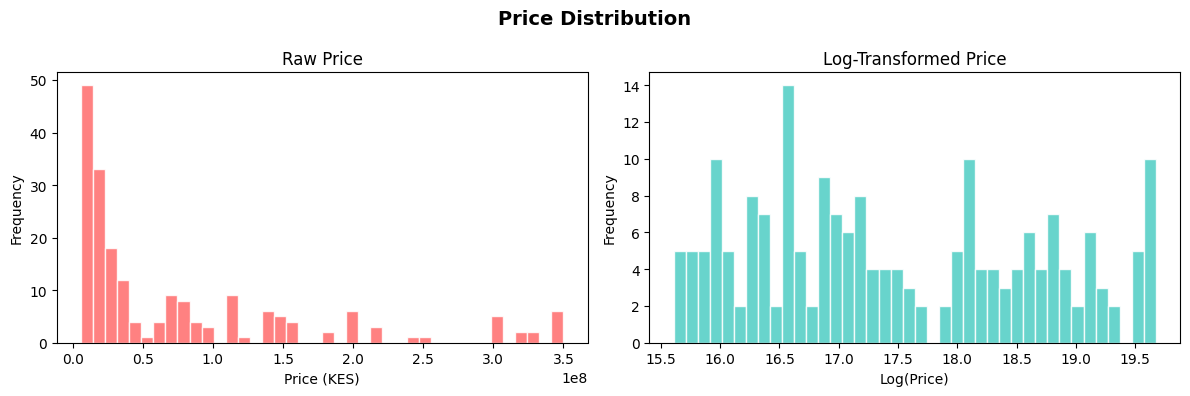

In [105]:
COLORS = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7',
          '#DDA0DD', '#98D8C8', '#F7DC6F', '#BB8FCE', '#85C1E9']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Price Distribution', fontsize=14, fontweight='bold')

axes[0].hist(df[price_col], bins=40, color='#FF6B6B', edgecolor='white', alpha=0.85)
axes[0].set_title('Raw Price')
axes[0].set_xlabel('Price (KES)')
axes[0].set_ylabel('Frequency')

axes[1].hist(np.log1p(df[price_col]), bins=40, color='#4ECDC4', edgecolor='white', alpha=0.85)
axes[1].set_title('Log-Transformed Price')
axes[1].set_xlabel('Log(Price)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('plot_price_dist.png', dpi=100, bbox_inches='tight')
plt.show()

Top locations using the median price

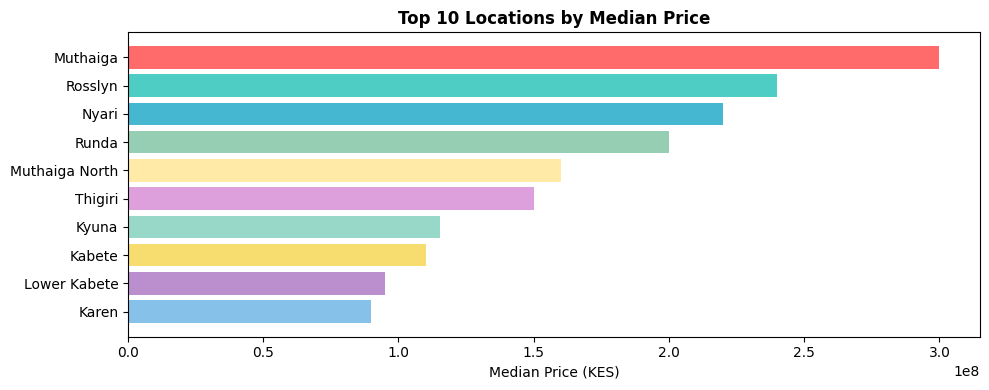

In [106]:
location_col = [c for c in df.columns if 'location' in c or 'area' in c or 'neighbourhood' in c][0]

top_locations = (
    df.groupby(location_col)[price_col]
    .median()
    .sort_values(ascending=False)
    .head(10)
)

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(top_locations.index, top_locations.values, color=COLORS)
ax.set_title('Top 10 Locations by Median Price', fontweight='bold')
ax.set_xlabel('Median Price (KES)')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('plot_top_locations.png', dpi=100, bbox_inches='tight')
plt.show()

Correlation heatmap

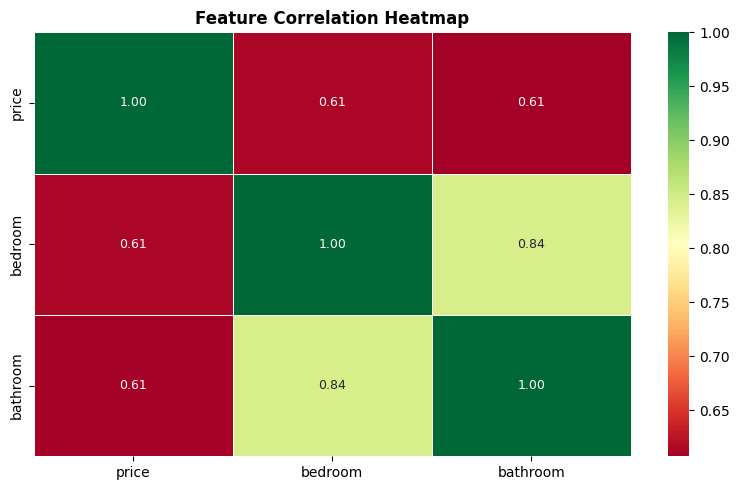

In [107]:
numeric_df = df.select_dtypes(include=np.number)
corr = numeric_df.corr()

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(
    corr, annot=True, fmt='.2f', cmap='RdYlGn',
    linewidths=0.5, ax=ax, annot_kws={'size': 9}
)
ax.set_title('Feature Correlation Heatmap', fontweight='bold')
plt.tight_layout()
plt.savefig('plot_correlation.png', dpi=100, bbox_inches='tight')
plt.show()

PHASE TWO

6. Model building

AI ALGORITHM. USING DECORATORS AND RECURSION TO BUILD THE AI MODELS - Linear Regression and Random Forest

DECORATORS

In [108]:
import time
import functools

def timer(func):
    """Decorator that prints how long a function takes to run."""
    @functools.wraps(func)
    def wrapper(*args, **kwargs):
        start = time.time()
        result = func(*args, **kwargs)
        end = time.time()
        print(f'[{func.__name__}] completed in {end - start:.3f}s')
        return result
    return wrapper


def validate_input(func):
    """Decorator that checks X and y are not empty before training."""
    @functools.wraps(func)
    def wrapper(X, y, *args, **kwargs):
        if X is None or y is None:
            raise ValueError('X and y cannot be None.')
        if len(X) == 0 or len(y) == 0:
            raise ValueError('X and y cannot be empty.')
        print(f'[{func.__name__}] Input validated: {X.shape[0]} samples, {X.shape[1]} features.')
        return func(X, y, *args, **kwargs)
    return wrapper


print('Decorators defined.')

Decorators defined.


Recurssion

Recursive mean

In [109]:
def recursive_mean(values, index=0, total=0):
    """
    Recursively calculates the mean of a list of values.
    """
    if index == len(values):
        return total / len(values)
    return recursive_mean(values, index + 1, total + values[index])

Testing

In [110]:
price_list = df[price_col].tolist()[:500]  
rec_mean = recursive_mean(price_list)
print(f'Recursive mean of first 500 prices: KES {rec_mean:,.0f}')
print(f'Pandas mean (verification):          KES {df[price_col].head(500).mean():,.0f}')

Recursive mean of first 500 prices: KES 77,433,002
Pandas mean (verification):          KES 77,433,002


Recursive feature summary and testing

In [111]:
def recursive_feature_summary(columns, dataframe, index=0, results=None):
    """
    Recursively builds a summary dictionary of min/max for each column.
    """
    if results is None:
        results = {}
    if index == len(columns):
        return results
    col = columns[index]
    if dataframe[col].dtype in ['float64', 'int64']:
        results[col] = {
            'min': dataframe[col].min(),
            'max': dataframe[col].max()
        }
    return recursive_feature_summary(columns, dataframe, index + 1, results)

In [112]:
summary = recursive_feature_summary(df.columns.tolist(), df)
print('\nRecursive Feature Summary (min/max):')
for col, stats in summary.items():
    print(f'  {col}: min={stats["min"]:,.2f}, max={stats["max"]:,.2f}')


Recursive Feature Summary (min/max):
  price: min=6,000,000.00, max=350,000,000.00
  bedroom: min=1.00, max=8.00
  bathroom: min=1.00, max=8.00


Feature encoding and preparation

In [113]:
df_model = df.copy()

Encoding categorical variables

In [114]:
label_encoders = {}
cat_cols = df_model.select_dtypes(include='object').columns.tolist()

for col in cat_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].astype(str))
    label_encoders[col] = le

print('Categorical columns encoded:', cat_cols)

Categorical columns encoded: ['propertytype', 'location', 'house_size', 'land_size']


Defining features and target. Transform using log for better performance of the model

In [115]:
X = df_model.drop(columns=[price_col])
y = np.log1p(df_model[price_col])

Feature scaling

In [116]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

Splitting the data

In [117]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)
print(f'Train size: {X_train.shape[0]}  |  Test size: {X_test.shape[0]}')

Train size: 158  |  Test size: 40


Training the AI models with decorators

In [118]:
@timer
@validate_input
def train_linear_regression(X, y):
    model = LinearRegression()
    model.fit(X, y)
    return model


@timer
@validate_input
def train_random_forest(X, y, n_estimators=100, max_depth=10):
    model = RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        random_state=42,
        n_jobs=-1
    )
    model.fit(X, y)
    return model


def evaluate_model(model, X_test, y_test, model_name):
    preds = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    print(f'\n{model_name} Results:')
    print(f'  RMSE : {rmse:.4f}')
    print(f'  MAE  : {mae:.4f}')
    print(f'  R2   : {r2:.4f}')
    return {'model': model_name, 'RMSE': rmse, 'MAE': mae, 'R2': r2, 'predictions': preds}

Training and evaluating the models

In [119]:
lr_model = train_linear_regression(X_train, y_train)
rf_model = train_random_forest(X_train, y_train)

[train_linear_regression] Input validated: 158 samples, 6 features.
[train_linear_regression] completed in 0.008s
[train_random_forest] Input validated: 158 samples, 6 features.
[train_random_forest] completed in 0.274s


6. Model evaluation

In [120]:
lr_results = evaluate_model(lr_model, X_test, y_test, 'Linear Regression')
rf_results = evaluate_model(rf_model, X_test, y_test, 'Random Forest')


Linear Regression Results:
  RMSE : 0.5920
  MAE  : 0.4589
  R2   : 0.7222

Random Forest Results:
  RMSE : 0.4533
  MAE  : 0.3234
  R2   : 0.8371


Explanation:
Random Forest is the better model across all three metrics:

Higher R² (0.84 vs 0.71) — it explains more of the variance the target variable
Lower RMSE (0.45 vs 0.61) — its predictions are closer to the actual values on average
Lower MAE (0.32 vs 0.47) — smaller average absolute error

Random Forest is likely performing better because it captures non-linear relationships in your data that Linear Regression can't

Model comparison chart

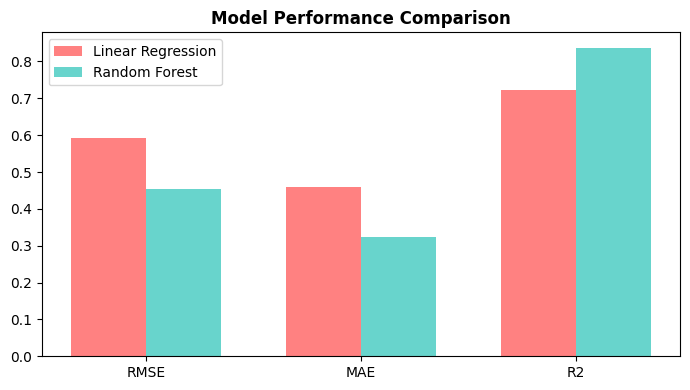

In [121]:
metrics = ['RMSE', 'MAE', 'R2']
lr_vals = [lr_results['RMSE'], lr_results['MAE'], lr_results['R2']]
rf_vals = [rf_results['RMSE'], rf_results['MAE'], rf_results['R2']]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x - width/2, lr_vals, width, label='Linear Regression', color='#FF6B6B', alpha=0.85)
ax.bar(x + width/2, rf_vals, width, label='Random Forest', color='#4ECDC4', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_title('Model Performance Comparison', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('plot_model_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

Feature importance using Random forest

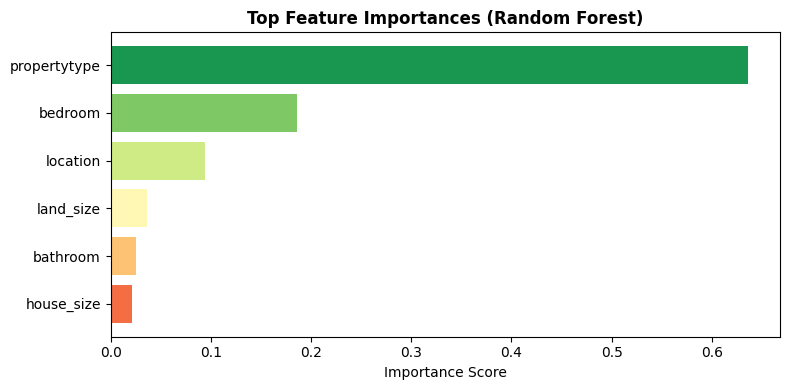

In [122]:
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=True).tail(10)

fig, ax = plt.subplots(figsize=(8, 4))
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(importances)))
ax.barh(importances.index, importances.values, color=colors)
ax.set_title('Top Feature Importances (Random Forest)', fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('plot_feature_importance.png', dpi=100, bbox_inches='tight')
plt.show()

7. Deployment

OBJECT ORIENTED PROGRAMMING

OOP Design

In [123]:
class HousingDataProcessor:
    """
    Handles all data cleaning and preprocessing steps.
    """
    def __init__(self, dataframe):
        self.df = dataframe.copy()
        self.label_encoders = {}
        self.scaler = StandardScaler()
        self.price_col = None

    def detect_price_column(self):
        self.price_col = [c for c in self.df.columns if 'price' in c][0]
        print(f'Price column detected: {self.price_col}')
        return self

    def clean(self):
        self.df = fill_missing_values(self.df)
        self.df = remove_outliers(self.df, self.price_col)
        return self

    def encode(self):
        for col in self.df.select_dtypes(include='object').columns:
            le = LabelEncoder()
            self.df[col] = le.fit_transform(self.df[col].astype(str))
            self.label_encoders[col] = le
        return self

    def get_features_and_target(self):
        X = self.df.drop(columns=[self.price_col])
        y = np.log1p(self.df[self.price_col])
        X_scaled = self.scaler.fit_transform(X)
        return pd.DataFrame(X_scaled, columns=X.columns), y


class HousingPricePredictor:
    """
    Wraps model training, evaluation, saving and prediction.
    """

    def __init__(self, model_type='random_forest'):
        self.model_type = model_type
        self.model = None
        self.metrics = {}
        self._build_model()

    def _build_model(self):
        if self.model_type == 'linear_regression':
            self.model = LinearRegression()
        elif self.model_type == 'random_forest':
            self.model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
        else:
            raise ValueError(f'Unknown model type: {self.model_type}')

    def train(self, X_train, y_train):
        self.model.fit(X_train, y_train)
        print(f'{self.model_type} trained successfully.')
        return self

    def evaluate(self, X_test, y_test):
        preds = self.model.predict(X_test)
        self.metrics = {
            'RMSE': round(np.sqrt(mean_squared_error(y_test, preds)), 4),
            'MAE': round(mean_absolute_error(y_test, preds), 4),
            'R2': round(r2_score(y_test, preds), 4)
        }
        print(f'Metrics for {self.model_type}: {self.metrics}')
        return self.metrics

    def predict(self, input_features):
        pred_log = self.model.predict([input_features])[0]
        return np.expm1(pred_log)  

    def save(self, path):
        joblib.dump(self.model, path)
        print(f'Model saved to {path}')

    @classmethod
    def load(cls, path, model_type):
        instance = cls.__new__(cls)
        instance.model_type = model_type
        instance.model = joblib.load(path)
        instance.metrics = {}
        print(f'Model loaded from {path}')
        return instance



Running the OOP pipeline

In [124]:
processor = HousingDataProcessor(df)
processor.detect_price_column().clean().encode()
X_oop, y_oop = processor.get_features_and_target()

Price column detected: price
Missing values filled.
Outlier removal on [price]: 2 rows removed.


In [125]:
X_tr, X_te, y_tr, y_te = train_test_split(X_oop, y_oop, test_size=0.2, random_state=42)

rf_predictor = HousingPricePredictor(model_type='random_forest')
rf_predictor.train(X_tr, y_tr)
rf_predictor.evaluate(X_te, y_te)

random_forest trained successfully.
Metrics for random_forest: {'RMSE': np.float64(0.4082), 'MAE': 0.2799, 'R2': 0.8777}


{'RMSE': np.float64(0.4082), 'MAE': 0.2799, 'R2': 0.8777}

In [126]:
lr_predictor = HousingPricePredictor(model_type='linear_regression')
lr_predictor.train(X_tr, y_tr)
lr_predictor.evaluate(X_te, y_te)

linear_regression trained successfully.
Metrics for linear_regression: {'RMSE': np.float64(0.6019), 'MAE': 0.4567, 'R2': 0.7341}


{'RMSE': np.float64(0.6019), 'MAE': 0.4567, 'R2': 0.7341}

Saving the models

In [127]:
os.makedirs('model_assets', exist_ok=True)

rf_predictor.save('model_assets/random_forest_model.pkl')
lr_predictor.save('model_assets/linear_regression_model.pkl')
joblib.dump(processor.scaler, 'model_assets/scaler.pkl')
joblib.dump(processor.label_encoders, 'model_assets/label_encoders.pkl')
joblib.dump(X_oop.columns.tolist(), 'model_assets/feature_columns.pkl')

Model saved to model_assets/random_forest_model.pkl
Model saved to model_assets/linear_regression_model.pkl


['model_assets/feature_columns.pkl']

In [128]:
import json
metrics_dict = {
    'random_forest': rf_predictor.metrics,
    'linear_regression': lr_predictor.metrics
}
with open('model_assets/metrics.json', 'w') as f:
    json.dump(metrics_dict, f)

print('All assets saved to model_assets/')

All assets saved to model_assets/


In [129]:
print(df['propertytype'].unique())

['Townhouse' 'Vacant Land' 'Apartment' 'Commercial Property'
 'Industrial Property']
